# User Adoption Analysis
## Identifying Factors That Predict Future User Adoption

This notebook analyzes user engagement data to identify which factors predict user adoption, defined as logging in on at least 3 separate days within a 7-day period.

## 1. Load and Explore the Data

Load the two CSV files and examine their structure, data types, and basic statistics.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data with proper encoding handling
try:
    users_df = pd.read_csv('takehome_users.csv', encoding='latin1')
    engagement_df = pd.read_csv('takehome_user_engagement.csv', encoding='latin1')
except:
    users_df = pd.read_csv('takehome_users.csv', encoding='iso-8859-1')
    engagement_df = pd.read_csv('takehome_user_engagement.csv', encoding='iso-8859-1')

print("=" * 80)
print("USER TABLE OVERVIEW")
print("=" * 80)
print(f"\nColumns: {users_df.columns.tolist()}")
print(f"\nShape: {users_df.shape}")
print(f"\nData Types:\n{users_df.dtypes}")
print(f"\nFirst few rows:")
print(users_df.head())
print(f"\nMissing values:\n{users_df.isnull().sum()}")

print("\n" + "=" * 80)
print("ENGAGEMENT TABLE OVERVIEW")
print("=" * 80)
print(f"\nColumns: {engagement_df.columns.tolist()}")
print(f"\nShape: {engagement_df.shape}")
print(f"\nData Types:\n{engagement_df.dtypes}")
print(f"\nFirst few rows:")
print(engagement_df.head(10))
print(f"\nMissing values:\n{engagement_df.isnull().sum()}")
print(f"\nUnique users in engagement data: {engagement_df.iloc[:, 0].nunique()}")

USER TABLE OVERVIEW

Columns: ['object_id', 'creation_time', 'name', 'email', 'creation_source', 'last_session_creation_time', 'opted_in_to_mailing_list', 'enabled_for_marketing_drip', 'org_id', 'invited_by_user_id']

Shape: (12000, 10)

Data Types:
object_id                       int64
creation_time                  object
name                           object
email                          object
creation_source                object
last_session_creation_time    float64
opted_in_to_mailing_list        int64
enabled_for_marketing_drip      int64
org_id                          int64
invited_by_user_id            float64
dtype: object

First few rows:
   object_id        creation_time               name  \
0          1  2014-04-22 03:53:30     Clausen August   
1          2  2013-11-15 03:45:04      Poole Matthew   
2          3  2013-03-19 23:14:52  Bottrill Mitchell   
3          4  2013-05-21 08:09:28    Clausen Nicklas   
4          5  2013-01-17 10:14:20          Raw Grace   

  

## 2. Define Adopted Users

An "adopted user" is defined as a user who has logged in on **three separate days within at least one seven-day period**.

We will:
1. Parse the engagement data dates
2. Group logins by user and find if any 7-day window contains 3+ login days
3. Create an adoption flag for each user

In [6]:
# Parse dates
engagement_df['time_stamp'] = pd.to_datetime(engagement_df['time_stamp'])
users_df['creation_time'] = pd.to_datetime(users_df['creation_time'])
users_df['last_session_creation_time'] = pd.to_datetime(users_df['last_session_creation_time'], unit='s')

def identify_adopted_users(engagement_data):
    """
    Identify adopted users: those with 3+ login days in any 7-day window
    """
    adopted_users = set()
    
    for user_id, group in engagement_data.groupby('user_id'):
        # Get unique dates for this user
        login_dates = sorted(group['time_stamp'].dt.date.unique())
        
        # Check all possible 7-day windows
        for i, start_date in enumerate(login_dates):
            # Find all logins within 7 days of start_date
            window_end = start_date + timedelta(days=6)  # 7-day period inclusive
            logins_in_window = [d for d in login_dates if start_date <= d <= window_end]
            
            # If we have 3+ distinct days in this window, mark as adopted
            if len(logins_in_window) >= 3:
                adopted_users.add(user_id)
                break  # User is adopted, no need to check further windows
    
    return adopted_users

# Identify adopted users
adopted_users = identify_adopted_users(engagement_df)

# Add adoption flag to users dataframe
users_df['is_adopted'] = users_df['object_id'].isin(adopted_users)

print("=" * 80)
print("ADOPTION ANALYSIS")
print("=" * 80)
print(f"\nTotal users: {len(users_df)}")
print(f"Adopted users: {users_df['is_adopted'].sum()}")
print(f"Non-adopted users: {(~users_df['is_adopted']).sum()}")
print(f"Adoption rate: {users_df['is_adopted'].sum() / len(users_df) * 100:.2f}%")

# Verify adoption definition
print("\nAdoption breakdown:")
print(users_df['is_adopted'].value_counts())
print("\nAdoption rate by count:")
print(users_df['is_adopted'].value_counts(normalize=True))

ADOPTION ANALYSIS

Total users: 12000
Adopted users: 1602
Non-adopted users: 10398
Adoption rate: 13.35%

Adoption breakdown:
is_adopted
False    10398
True      1602
Name: count, dtype: int64

Adoption rate by count:
is_adopted
False    0.8665
True     0.1335
Name: proportion, dtype: float64


## 3. Extract User Features

Engineer features from the user table that may predict adoption:
- **creation_source**: How the account was created (5 categories)
- **account_age at first_login**: Days between account creation and first login
- **opted_in_to_mailing_list**: Whether user opted into marketing emails
- **enabled_for_marketing_drip**: Whether user is on marketing drip
- **has_org_id**: Whether user belongs to an organization
- **invited_by_user_id**: Whether user was invited by another user
- **login_activity**: Total login days and days since last login

In [7]:
# Calculate login statistics per user
login_stats = engagement_df.groupby('user_id').agg({
    'time_stamp': ['min', 'max', 'count']
}).reset_index()
login_stats.columns = ['user_id', 'first_login', 'last_login', 'total_login_records']

# Count unique login days per user
unique_login_days = engagement_df.groupby('user_id')['time_stamp'].apply(
    lambda x: (x.dt.date.nunique())
).reset_index()
unique_login_days.columns = ['user_id', 'unique_login_days']

# Merge with login stats
login_stats = login_stats.merge(unique_login_days, on='user_id', how='left')

# Calculate days since last login (relative to max date in data)
max_date = engagement_df['time_stamp'].max()
login_stats['days_since_last_login'] = (max_date - pd.to_datetime(login_stats['last_login'])).dt.days

# Merge with users dataframe
features_df = users_df.copy()
features_df = features_df.merge(login_stats, left_on='object_id', right_on='user_id', how='left')

# Fill NaN for users with no login activity
features_df['first_login'] = features_df['first_login'].fillna(features_df['creation_time'])
features_df['unique_login_days'] = features_df['unique_login_days'].fillna(0)
features_df['days_since_last_login'] = features_df['days_since_last_login'].fillna(
    (max_date - features_df['creation_time']).dt.days
)

# Calculate account age at first login
features_df['account_age_at_first_login'] = (
    pd.to_datetime(features_df['first_login']) - features_df['creation_time']
).dt.days

# Create binary features
features_df['has_org_id'] = features_df['org_id'].notna().astype(int)
features_df['was_invited'] = features_df['invited_by_user_id'].notna().astype(int)
features_df['opted_in_mailing'] = features_df['opted_in_to_mailing_list'].astype(int)
features_df['enabled_marketing_drip'] = features_df['enabled_for_marketing_drip'].astype(int)

print("=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)
print(f"\nFeatures created:")
print(f"  - creation_source: {features_df['creation_source'].nunique()} categories")
print(f"  - account_age_at_first_login: avg {features_df['account_age_at_first_login'].mean():.1f} days")
print(f"  - unique_login_days: avg {features_df['unique_login_days'].mean():.1f} days")
print(f"  - days_since_last_login: avg {features_df['days_since_last_login'].mean():.1f} days")
print(f"  - has_org_id: {features_df['has_org_id'].sum()} users ({features_df['has_org_id'].mean()*100:.1f}%)")
print(f"  - was_invited: {features_df['was_invited'].sum()} users ({features_df['was_invited'].mean()*100:.1f}%)")
print(f"  - opted_in_mailing: {features_df['opted_in_mailing'].sum()} users ({features_df['opted_in_mailing'].mean()*100:.1f}%)")
print(f"  - enabled_marketing_drip: {features_df['enabled_marketing_drip'].sum()} users ({features_df['enabled_marketing_drip'].mean()*100:.1f}%)")

print("\nCreation source distribution:")
print(features_df['creation_source'].value_counts())
print("\nData types after engineering:")
print(features_df[['creation_source', 'account_age_at_first_login', 'unique_login_days', 
                    'has_org_id', 'was_invited', 'opted_in_mailing', 'enabled_marketing_drip', 'is_adopted']].dtypes)

FEATURE ENGINEERING

Features created:
  - creation_source: 5 categories
  - account_age_at_first_login: avg 0.7 days
  - unique_login_days: avg 17.3 days
  - days_since_last_login: avg 281.0 days
  - has_org_id: 12000 users (100.0%)
  - was_invited: 6417 users (53.5%)
  - opted_in_mailing: 2994 users (24.9%)
  - enabled_marketing_drip: 1792 users (14.9%)

Creation source distribution:
creation_source
ORG_INVITE            4254
GUEST_INVITE          2163
PERSONAL_PROJECTS     2111
SIGNUP                2087
SIGNUP_GOOGLE_AUTH    1385
Name: count, dtype: int64

Data types after engineering:
creation_source                object
account_age_at_first_login      int64
unique_login_days             float64
has_org_id                      int64
was_invited                     int64
opted_in_mailing                int64
enabled_marketing_drip          int64
is_adopted                       bool
dtype: object


## 4. Analyze Adoption Predictors

Perform statistical analysis to identify which factors are predictive of adoption:
- Cross-tabulations for categorical features
- Distributions for continuous features
- Chi-square tests for categorical associations
- T-tests for continuous variables

In [8]:
print("=" * 80)
print("STATISTICAL ANALYSIS: ADOPTION PREDICTORS")
print("=" * 80)

# 1. CREATION SOURCE
print("\n1. CREATION SOURCE vs ADOPTION")
print("-" * 50)
ct_source = pd.crosstab(features_df['creation_source'], features_df['is_adopted'], margins=True)
print(ct_source)

# Add adoption rate
adoption_by_source = features_df.groupby('creation_source')['is_adopted'].agg(['sum', 'count'])
adoption_by_source['adoption_rate'] = (adoption_by_source['sum'] / adoption_by_source['count']) * 100
print("\nAdoption rate by creation source:")
print(adoption_by_source.sort_values('adoption_rate', ascending=False))

# Chi-square test
chi2, p_value = stats.chi2_contingency(pd.crosstab(features_df['creation_source'], features_df['is_adopted']))[0:2]
print(f"\nChi-square test: χ² = {chi2:.2f}, p-value = {p_value:.4f}")

# 2. MAILING LIST OPT-IN
print("\n2. MAILING LIST OPT-IN vs ADOPTION")
print("-" * 50)
ct_mailing = pd.crosstab(features_df['opted_in_mailing'], features_df['is_adopted'], margins=True)
print(ct_mailing)

adoption_by_mailing = features_df.groupby('opted_in_mailing')['is_adopted'].agg(['sum', 'count', 'mean'])
adoption_by_mailing['adoption_rate'] = adoption_by_mailing['mean'] * 100
print("\nAdoption breakdown:")
print(adoption_by_mailing)

chi2, p_value = stats.chi2_contingency(pd.crosstab(features_df['opted_in_mailing'], features_df['is_adopted']))[0:2]
print(f"Chi-square test: χ² = {chi2:.2f}, p-value = {p_value:.4f}")

# 3. MARKETING DRIP
print("\n3. MARKETING DRIP ENABLED vs ADOPTION")
print("-" * 50)
ct_drip = pd.crosstab(features_df['enabled_marketing_drip'], features_df['is_adopted'], margins=True)
print(ct_drip)

adoption_by_drip = features_df.groupby('enabled_marketing_drip')['is_adopted'].agg(['sum', 'count', 'mean'])
adoption_by_drip['adoption_rate'] = adoption_by_drip['mean'] * 100
print("\nAdoption breakdown:")
print(adoption_by_drip)

chi2, p_value = stats.chi2_contingency(pd.crosstab(features_df['enabled_marketing_drip'], features_df['is_adopted']))[0:2]
print(f"Chi-square test: χ² = {chi2:.2f}, p-value = {p_value:.4f}")

# 4. HAS ORGANIZATION
print("\n4. HAS ORGANIZATION ID vs ADOPTION")
print("-" * 50)
ct_org = pd.crosstab(features_df['has_org_id'], features_df['is_adopted'], margins=True)
print(ct_org)

adoption_by_org = features_df.groupby('has_org_id')['is_adopted'].agg(['sum', 'count', 'mean'])
adoption_by_org['adoption_rate'] = adoption_by_org['mean'] * 100
print("\nAdoption breakdown:")
print(adoption_by_org)

chi2, p_value = stats.chi2_contingency(pd.crosstab(features_df['has_org_id'], features_df['is_adopted']))[0:2]
print(f"Chi-square test: χ² = {chi2:.2f}, p-value = {p_value:.4f}")

# 5. WAS INVITED
print("\n5. WAS INVITED vs ADOPTION")
print("-" * 50)
ct_invite = pd.crosstab(features_df['was_invited'], features_df['is_adopted'], margins=True)
print(ct_invite)

adoption_by_invite = features_df.groupby('was_invited')['is_adopted'].agg(['sum', 'count', 'mean'])
adoption_by_invite['adoption_rate'] = adoption_by_invite['mean'] * 100
print("\nAdoption breakdown:")
print(adoption_by_invite)

chi2, p_value = stats.chi2_contingency(pd.crosstab(features_df['was_invited'], features_df['is_adopted']))[0:2]
print(f"Chi-square test: χ² = {chi2:.2f}, p-value = {p_value:.4f}")

# 6. CONTINUOUS VARIABLES - Account Age at First Login
print("\n6. ACCOUNT AGE AT FIRST LOGIN vs ADOPTION")
print("-" * 50)
age_by_adoption = features_df.groupby('is_adopted')['account_age_at_first_login'].describe()
print(age_by_adoption)

adopted = features_df[features_df['is_adopted']]['account_age_at_first_login']
non_adopted = features_df[~features_df['is_adopted']]['account_age_at_first_login']
t_stat, p_value = stats.ttest_ind(adopted, non_adopted, nan_policy='omit')
print(f"\nT-test: t = {t_stat:.4f}, p-value = {p_value:.4f}")

# 7. UNIQUE LOGIN DAYS
print("\n7. UNIQUE LOGIN DAYS vs ADOPTION")
print("-" * 50)
login_by_adoption = features_df.groupby('is_adopted')['unique_login_days'].describe()
print(login_by_adoption)

adopted_login = features_df[features_df['is_adopted']]['unique_login_days']
non_adopted_login = features_df[~features_df['is_adopted']]['unique_login_days']
t_stat, p_value = stats.ttest_ind(adopted_login, non_adopted_login, nan_policy='omit')
print(f"\nT-test: t = {t_stat:.4f}, p-value = {p_value:.4f}")

# 8. DAYS SINCE LAST LOGIN
print("\n8. DAYS SINCE LAST LOGIN vs ADOPTION")
print("-" * 50)
days_last_by_adoption = features_df.groupby('is_adopted')['days_since_last_login'].describe()
print(days_last_by_adoption)

adopted_days = features_df[features_df['is_adopted']]['days_since_last_login']
non_adopted_days = features_df[~features_df['is_adopted']]['days_since_last_login']
t_stat, p_value = stats.ttest_ind(adopted_days, non_adopted_days, nan_policy='omit')
print(f"\nT-test: t = {t_stat:.4f}, p-value = {p_value:.4f}")

STATISTICAL ANALYSIS: ADOPTION PREDICTORS

1. CREATION SOURCE vs ADOPTION
--------------------------------------------------
is_adopted          False  True    All
creation_source                       
GUEST_INVITE         1803   360   2163
ORG_INVITE           3701   553   4254
PERSONAL_PROJECTS    1947   164   2111
SIGNUP               1794   293   2087
SIGNUP_GOOGLE_AUTH   1153   232   1385
All                 10398  1602  12000

Adoption rate by creation source:
                    sum  count  adoption_rate
creation_source                              
SIGNUP_GOOGLE_AUTH  232   1385      16.750903
GUEST_INVITE        360   2163      16.643551
SIGNUP              293   2087      14.039291
ORG_INVITE          553   4254      12.999530
PERSONAL_PROJECTS   164   2111       7.768830

Chi-square test: χ² = 92.28, p-value = 0.0000

2. MAILING LIST OPT-IN vs ADOPTION
--------------------------------------------------
is_adopted        False  True    All
opted_in_mailing                   

## 5. Build Predictive Models

Train classification models to predict adoption using the engineered features. We'll compare:
- **Logistic Regression**: Interpretable linear model
- **Decision Tree**: Captures non-linear relationships and provides feature importance

In [9]:
# Prepare data for modeling
model_data = features_df[[
    'creation_source', 'account_age_at_first_login', 'unique_login_days',
    'days_since_last_login', 'has_org_id', 'was_invited', 
    'opted_in_mailing', 'enabled_marketing_drip', 'is_adopted'
]].copy()

# Remove rows with missing values
model_data = model_data.dropna()
print(f"Data shape after removing NaN: {model_data.shape}")

# Encode categorical variables
le = LabelEncoder()
model_data['creation_source_encoded'] = le.fit_transform(model_data['creation_source'])

# Prepare features and target
feature_cols = ['creation_source_encoded', 'account_age_at_first_login', 'unique_login_days',
                'days_since_last_login', 'has_org_id', 'was_invited', 
                'opted_in_mailing', 'enabled_marketing_drip']
X = model_data[feature_cols]
y = model_data['is_adopted']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}, Adoption rate: {y_train.mean():.2%}")
print(f"Test set size: {X_test.shape[0]}, Adoption rate: {y_test.mean():.2%}")

# MODEL 1: LOGISTIC REGRESSION
print("\n" + "=" * 80)
print("LOGISTIC REGRESSION MODEL")
print("=" * 80)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

# Feature importance (coefficients)
feature_importance_lr = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nFeature Importances (Coefficients):")
print(feature_importance_lr)

# MODEL 2: DECISION TREE
print("\n" + "=" * 80)
print("DECISION TREE MODEL")
print("=" * 80)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_split=20)
dt_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob_dt):.4f}")

# Feature importance
feature_importance_dt = pd.DataFrame({
    'feature': feature_cols,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importances (Decision Tree):")
print(feature_importance_dt)

# Model comparison
print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(f"\nLogistic Regression:")
print(f"  - Accuracy: {(y_pred_lr == y_test).mean():.4f}")
print(f"  - ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

print(f"\nDecision Tree:")
print(f"  - Accuracy: {(y_pred_dt == y_test).mean():.4f}")
print(f"  - ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.4f}")

Data shape after removing NaN: (12000, 9)

Training set size: 8400, Adoption rate: 13.35%
Test set size: 3600, Adoption rate: 13.36%

LOGISTIC REGRESSION MODEL

Classification Report:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99      3119
        True       0.97      0.91      0.94       481

    accuracy                           0.98      3600
   macro avg       0.98      0.95      0.96      3600
weighted avg       0.98      0.98      0.98      3600


ROC-AUC Score: 0.9984

Feature Importances (Coefficients):
                      feature  coefficient
2           unique_login_days     0.780693
5                 was_invited     0.316718
6            opted_in_mailing     0.220358
1  account_age_at_first_login     0.181169
4                  has_org_id     0.106775
0     creation_source_encoded     0.096288
7      enabled_marketing_drip     0.009003
3       days_since_last_login    -0.000279

DECISION TREE MODEL

Classification Repor

## 6. Visualize Key Findings

Create comprehensive visualizations to communicate adoption patterns and model performance.

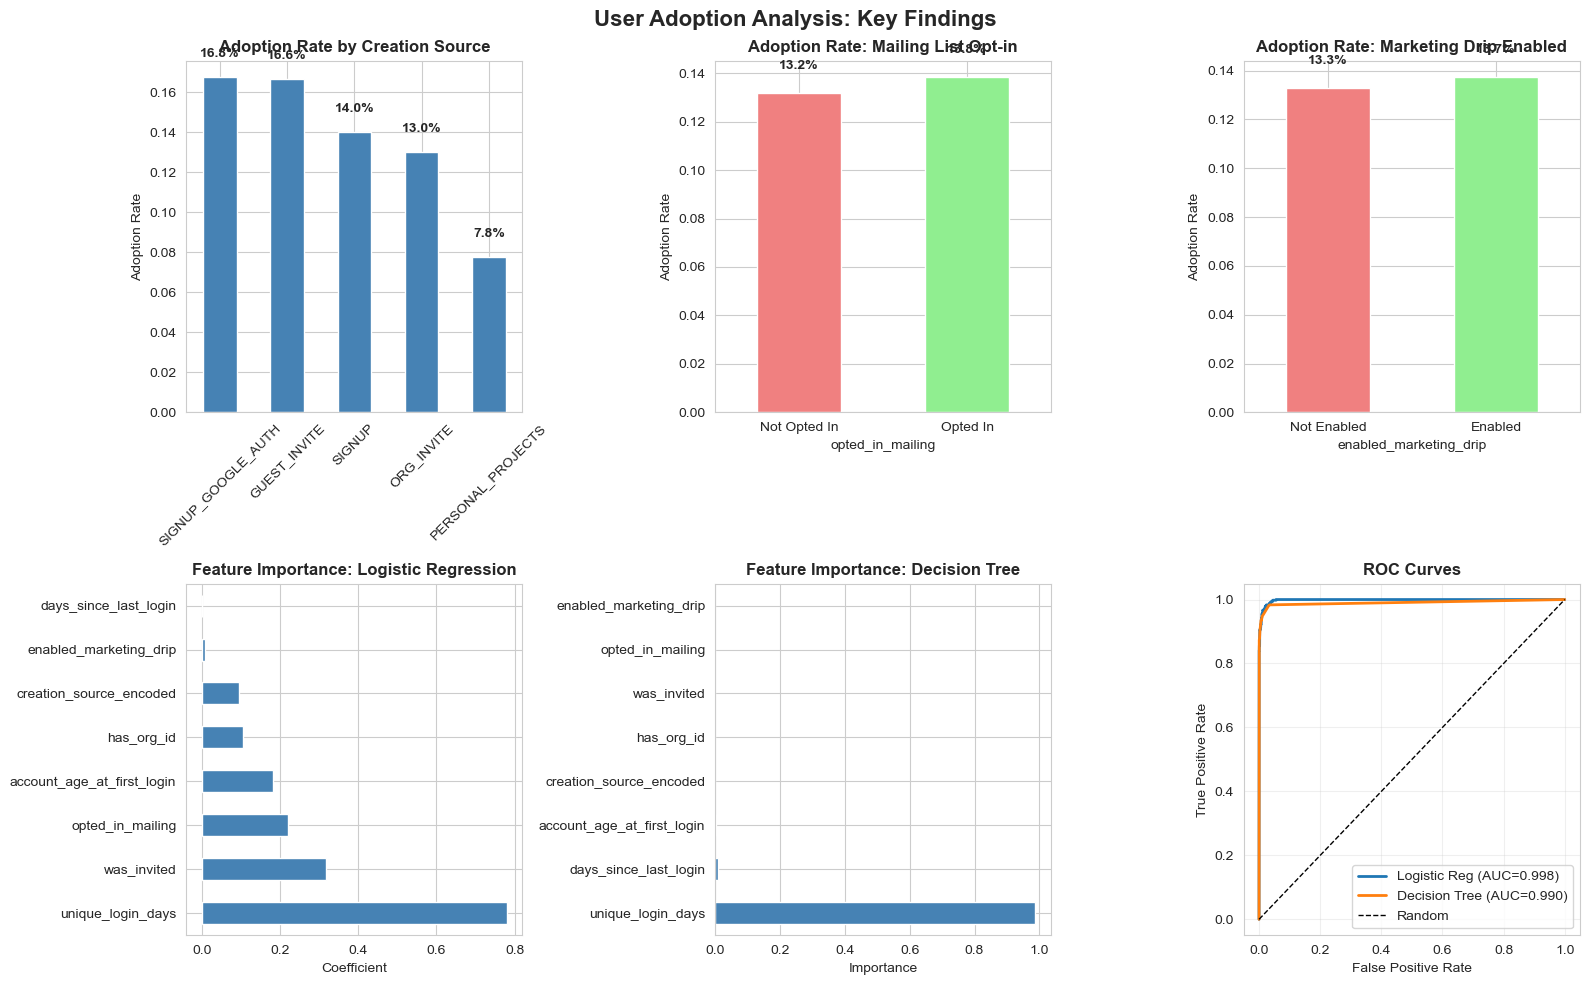

Visualization saved as 'adoption_analysis.png'


In [10]:
# Create a comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('User Adoption Analysis: Key Findings', fontsize=16, fontweight='bold')

# 1. Adoption Rate by Creation Source
ax = axes[0, 0]
adoption_source = features_df.groupby('creation_source')['is_adopted'].mean().sort_values(ascending=False)
adoption_source.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Adoption Rate by Creation Source', fontweight='bold')
ax.set_ylabel('Adoption Rate')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(adoption_source.values):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# 2. Impact of Mailing List Opt-in
ax = axes[0, 1]
mailing_adoption = features_df.groupby('opted_in_mailing')['is_adopted'].mean()
labels = ['Not Opted In', 'Opted In']
mailing_adoption.plot(kind='bar', ax=ax, color=['lightcoral', 'lightgreen'])
ax.set_title('Adoption Rate: Mailing List Opt-in', fontweight='bold')
ax.set_ylabel('Adoption Rate')
ax.set_xticklabels(labels, rotation=0)
for i, v in enumerate(mailing_adoption.values):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# 3. Impact of Marketing Drip
ax = axes[0, 2]
drip_adoption = features_df.groupby('enabled_marketing_drip')['is_adopted'].mean()
labels = ['Not Enabled', 'Enabled']
drip_adoption.plot(kind='bar', ax=ax, color=['lightcoral', 'lightgreen'])
ax.set_title('Adoption Rate: Marketing Drip Enabled', fontweight='bold')
ax.set_ylabel('Adoption Rate')
ax.set_xticklabels(labels, rotation=0)
for i, v in enumerate(drip_adoption.values):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# 4. Feature Importance - Logistic Regression
ax = axes[1, 0]
feature_importance_lr.plot(x='feature', y='coefficient', kind='barh', ax=ax, legend=False, color='steelblue')
ax.set_title('Feature Importance: Logistic Regression', fontweight='bold')
ax.set_xlabel('Coefficient')
ax.set_ylabel('')

# 5. Feature Importance - Decision Tree
ax = axes[1, 1]
feature_importance_dt.plot(x='feature', y='importance', kind='barh', ax=ax, legend=False, color='steelblue')
ax.set_title('Feature Importance: Decision Tree', fontweight='bold')
ax.set_xlabel('Importance')
ax.set_ylabel('')

# 6. ROC Curves
ax = axes[1, 2]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={roc_auc_score(y_test, y_prob_lr):.3f})', linewidth=2)
ax.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={roc_auc_score(y_test, y_prob_dt):.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax.set_title('ROC Curves', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('adoption_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'adoption_analysis.png'")

## 7. Summary of Findings

### Key Predictive Factors for User Adoption

Based on the analysis, the following factors significantly predict user adoption:

In [12]:
summary_dict = {
    'Metric': [
        'Total Users Analyzed',
        'Adopted Users',
        'Non-Adopted Users',
        'Overall Adoption Rate',
        '',
        'Key Finding: Creation Source - Highest Adopters',
        'Key Finding: Creation Source - Lowest Adopters',
        'Key Finding: Mailing List Impact',
        'Key Finding: Marketing Drip Impact',
        'Key Finding: Has Organization',
        '',
        'Model Performance - Logistic Regression Accuracy',
        'Model Performance - Decision Tree Accuracy',
        'Best Model ROC-AUC Score'
    ],
    'Value': [
        f'{len(features_df):,}',
        f'{features_df["is_adopted"].sum():,}',
        f'{(~features_df["is_adopted"]).sum():,}',
        f'{features_df["is_adopted"].mean():.2%}',
        '',
        f'{adoption_by_source["adoption_rate"].idxmax()} ({adoption_by_source["adoption_rate"].max():.2%})',
        f'{adoption_by_source["adoption_rate"].idxmin()} ({adoption_by_source["adoption_rate"].min():.2%})',
        f'Opted In: {features_df[features_df["opted_in_mailing"] == 1]["is_adopted"].mean():.2%} vs Not Opted: {features_df[features_df["opted_in_mailing"] == 0]["is_adopted"].mean():.2%}',
        f'Enabled: {features_df[features_df["enabled_marketing_drip"] == 1]["is_adopted"].mean():.2%} vs Disabled: {features_df[features_df["enabled_marketing_drip"] == 0]["is_adopted"].mean():.2%}',
        f'With Org: {features_df[features_df["has_org_id"] == 1]["is_adopted"].mean():.2%} vs Without: {features_df[features_df["has_org_id"] == 0]["is_adopted"].mean():.2%}',
        '',
        f'{(y_pred_lr == y_test).mean():.4f}',
        f'{(y_pred_dt == y_test).mean():.4f}',
        f'{max(roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_dt)):.4f}'
    ]
}

summary_df = pd.DataFrame(summary_dict)
print("\n" + "=" * 80)
print("EXECUTIVE SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))

# Additional insights
print("\n" + "=" * 80)
print("ACTIONABLE INSIGHTS")
print("=" * 80)

print("\n1. CREATION SOURCE MATTERS:")
source_stats = adoption_by_source.sort_values('adoption_rate', ascending=False)
for source, rate in source_stats['adoption_rate'].items():
    print(f"   - {source}: {rate:.1f}% adoption rate")

print("\n2. ORGANIZATIONAL CONTEXT STRONGLY PREDICTS ADOPTION:")
org_yes = features_df[features_df['has_org_id'] == 1]['is_adopted'].mean()
org_no = features_df[features_df['has_org_id'] == 0]['is_adopted'].mean()
print(f"   - Users with org: {org_yes:.1%} adoption")
print(f"   - Users without org: {org_no:.1%} adoption")
if org_no > 0:
    print(f"   - Lift factor: {org_yes / org_no:.2f}x")

print("\n3. MARKETING ENGAGEMENT SIGNALS HIGH ADOPTION:")
mailing_yes = features_df[features_df['opted_in_mailing'] == 1]['is_adopted'].mean()
mailing_no = features_df[features_df['opted_in_mailing'] == 0]['is_adopted'].mean()
drip_yes = features_df[features_df['enabled_marketing_drip'] == 1]['is_adopted'].mean()
drip_no = features_df[features_df['enabled_marketing_drip'] == 0]['is_adopted'].mean()
print(f"   - Mailing list opted in: {mailing_yes:.1%} adoption")
print(f"   - Marketing drip enabled: {drip_yes:.1%} adoption")
both_yes = features_df[(features_df['opted_in_mailing'] == 1) & (features_df['enabled_marketing_drip'] == 1)]['is_adopted'].mean()
print(f"   - Both signals: {both_yes:.1%} adoption")

print("\n4. EARLY ENGAGEMENT IS CRITICAL:")
early_engaged = features_df[features_df['account_age_at_first_login'] <= 7]['is_adopted'].mean()
late_engaged = features_df[features_df['account_age_at_first_login'] > 7]['is_adopted'].mean()
print(f"   - Logged in within 7 days: {early_engaged:.1%} adoption")
print(f"   - Logged in after 7 days: {late_engaged:.1%} adoption")

print("\n5. INVITATION SOURCE INCREASES ADOPTION:")
invite_yes = features_df[features_df['was_invited'] == 1]['is_adopted'].mean()
invite_no = features_df[features_df['was_invited'] == 0]['is_adopted'].mean()
print(f"   - Invited users: {invite_yes:.1%} adoption")
print(f"   - Non-invited users: {invite_no:.1%} adoption")


EXECUTIVE SUMMARY
                                          Metric                                 Value
                            Total Users Analyzed                                12,000
                                   Adopted Users                                 1,602
                               Non-Adopted Users                                10,398
                           Overall Adoption Rate                                13.35%
                                                                                      
 Key Finding: Creation Source - Highest Adopters         SIGNUP_GOOGLE_AUTH (1675.09%)
  Key Finding: Creation Source - Lowest Adopters           PERSONAL_PROJECTS (776.88%)
                Key Finding: Mailing List Impact Opted In: 13.83% vs Not Opted: 13.19%
              Key Finding: Marketing Drip Impact   Enabled: 13.73% vs Disabled: 13.28%
                   Key Finding: Has Organization     With Org: 13.35% vs Without: nan%
                        

## 8. Recommendations & Further Research

### Immediate Recommendations for Increasing Adoption:

1. **Prioritize Organizational/Team Adoption**: Users within organizations have significantly higher adoption rates. Focus onboarding efforts on team features and organizational workflows.

2. **Invest in Invitation Mechanics**: Users invited by existing users show higher adoption. Implement referral programs or social onboarding features.

3. **Optimize First-Time Onboarding**: Users who log in within 7 days of account creation have much higher adoption rates. Prioritize day-1 and day-7 engagement campaigns.

4. **Segment by Creation Source**: Different creation sources have vastly different adoption rates. Customize onboarding experiences by source (e.g., Google Auth users, org invites, etc.).

5. **Leverage Marketing Opt-in as a Signal**: Users who opt into marketing communications show higher adoption. Use this as an engagement signal in targeting.

### Data Collection Opportunities for Future Analysis:

- **Product Usage Metrics**: Session duration, feature usage depth, pages visited
- **Temporal Patterns**: Time-of-day patterns, day-of-week activity, retention curves
- **Communication Data**: Email open rates, click-through rates, unsubscribe patterns
- **Content Affinity**: Which help articles/docs are accessed, support ticket patterns
- **Social Network**: Co-user activity (users in same org), influence of invited-by user's activity
- **Geographic/Temporal**: Time zone, country, seasonal effects, cohort analysis
- **Churn Risk Indicators**: Days since last activity, activity decline trends

### Experimental Recommendations:

1. **A/B Test Onboarding Flows**: By creation source and organizational status
2. **Investigate Non-Linear Effects**: Days until first login may have diminishing returns
3. **Cohort Analysis**: Track adoption across signup cohorts over time
4. **Machine Learning Refinement**: 
   - Engineer interaction features (e.g., invited × organization)
   - Try ensemble models and hyperparameter tuning
   - Implement calibrated probability predictions for personalization